2025-02-13 10:22:51,759 - INFO - Loading spectral data...
2025-02-13 10:22:51,761 - INFO - Processing XYZ data...
2025-02-13 10:22:51,761 - INFO - Normalizing data...
2025-02-13 10:22:51,763 - INFO - Training the model...
2025-02-13 10:22:51,766 - INFO - Epoch 1/300 - MSE Loss: 0.07925500720739365
2025-02-13 10:22:51,769 - INFO - Epoch 2/300 - MSE Loss: 0.04058042913675308
2025-02-13 10:22:51,771 - INFO - Epoch 3/300 - MSE Loss: 0.03859749063849449
2025-02-13 10:22:51,773 - INFO - Epoch 4/300 - MSE Loss: 0.02556621842086315
2025-02-13 10:22:51,774 - INFO - Epoch 5/300 - MSE Loss: 0.016880173236131668
2025-02-13 10:22:51,776 - INFO - Epoch 6/300 - MSE Loss: 0.005672730505466461
2025-02-13 10:22:51,778 - INFO - Epoch 7/300 - MSE Loss: 0.00925979670137167
2025-02-13 10:22:51,780 - INFO - Epoch 8/300 - MSE Loss: 0.008924640715122223
2025-02-13 10:22:51,782 - INFO - Epoch 9/300 - MSE Loss: 0.009639434516429901
2025-02-13 10:22:51,783 - INFO - Epoch 10/300 - MSE Loss: 0.008907370269298553
20

Mean ΔE2000 Error: 6.928558407634041
Max ΔE2000 Error: 15.852745423003931


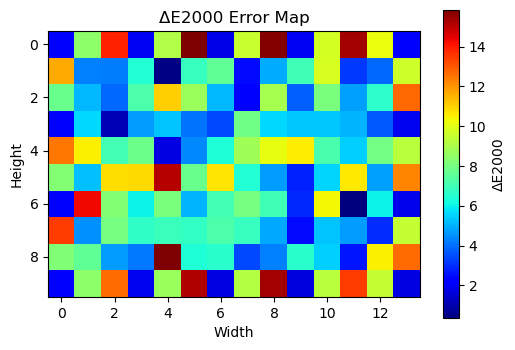

In [16]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import logging
from sklearn.preprocessing import MinMaxScaler
import spectral
import random
from skimage import color
import matplotlib.pyplot as plt

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Set a fixed seed for reproducibility
seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # If using GPU

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

###########################################
# Helper functions
###########################################
def process_xyz(cube, bands, ill, CMFs):
    """
    Converts hyperspectral cube data to XYZ.
    """
    ill_interp = np.interp(bands, ill[:, 0], ill[:, 1])
    CMFs_interp = np.column_stack([
        np.interp(bands, CMFs[:, 0], CMFs[:, 1]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 2]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 3])
    ])
    sp_tristREF = CMFs_interp * ill_interp[:, None]
    xyz = np.dot(cube, sp_tristREF) / np.sum(sp_tristREF[:, 1], axis=0)
    return xyz

###########################################
# 1. Load spectral data
###########################################
logging.info('Loading spectral data...')
ill = np.loadtxt('../../data/CIE_D65.txt')          
CMFs = np.loadtxt('../../data/CIE2degCMFs_1931.txt')

cube = spectral.open_image('../../data/colorChecker_SG/cubes/cubeCC_120f-velvia-f8.hdr')
# cube = spectral.open_image('../../data/colorChecker_SG/cubes/cubeCC_120f-velvia-f8.hdr')
cube_ref = spectral.open_image('../../data/colorChecker_SG/cubeCC_DigitalSG_REF.hdr')

cube_data = cube.load()         
cube_ref_data = cube_ref.load()

wl_input = np.array(cube.metadata['wavelength'], dtype=float)
wl_ref   = np.array(cube_ref.metadata['wavelength'], dtype=float)

###########################################
# 2. Process XYZ data
###########################################
logging.info('Processing XYZ data...')
xyz_input = process_xyz(cube_data, wl_input, ill, CMFs)   
xyz_ref   = process_xyz(cube_ref_data, wl_ref, ill, CMFs)   

###########################################
# 3. Normalize data
###########################################
logging.info('Normalizing data...')
xyz_input_2d = xyz_input.reshape(-1, xyz_input.shape[-1])
xyz_ref_2d   = xyz_ref.reshape(-1, xyz_ref.shape[-1])

scaler_input = MinMaxScaler()
scaler_ref = MinMaxScaler()
X_norm = scaler_input.fit_transform(xyz_input_2d)
Y_norm = scaler_ref.fit_transform(xyz_ref_2d)

X_full = X_norm.reshape(xyz_input.shape)
Y_full = Y_norm.reshape(xyz_ref.shape)

###########################################
# 4. Prepare training data
###########################################
X_flat = X_full.reshape(-1, 3)
Y_flat = Y_full.reshape(-1, 3)

n_pixels = X_flat.shape[0]
train_size = int(0.8 * n_pixels)
train_indices = np.random.choice(n_pixels, train_size, replace=False)
test_indices = np.setdiff1d(np.arange(n_pixels), train_indices)

X_train_split = X_flat[train_indices]
X_test_split  = X_flat[test_indices]
Y_train_split = Y_flat[train_indices]
Y_test_split  = Y_flat[test_indices]

X_train_torch = torch.tensor(X_train_split, dtype=torch.float32)
Y_train_torch = torch.tensor(Y_train_split, dtype=torch.float32)
X_test_torch  = torch.tensor(X_test_split, dtype=torch.float32)
Y_test_torch  = torch.tensor(Y_test_split, dtype=torch.float32)

###########################################
# 5. Define the NN
###########################################
class InvariantNN(nn.Module):
    def __init__(self, input_size=3, hidden_size=79, hidden_size2=36, output_size=3):
        super(InvariantNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.elu = nn.ELU()
        self.fc2 = nn.Linear(hidden_size, hidden_size2)
        self.elu2 = nn.ELU()
        self.fc3 = nn.Linear(hidden_size2, output_size)
    def forward(self, x):
        x = self.elu(self.fc1(x))
        x = self.elu2(self.fc2(x))
        return self.fc3(x)

model = InvariantNN()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_function = nn.MSELoss()

###########################################
# 6. Training loop
###########################################
epochs = 300
batch_size = 32

logging.info('Training the model...')
for epoch in range(epochs):
    model.train()
    perm = torch.randperm(X_train_torch.size(0))
    X_train_shuffled = X_train_torch[perm]
    Y_train_shuffled = Y_train_torch[perm]
    
    for i in range(0, X_train_shuffled.size(0), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        Y_batch = Y_train_shuffled[i:i+batch_size]
        
        optimizer.zero_grad()
        Y_pred = model(X_batch)
        loss = loss_function(Y_pred, Y_batch)
        loss.backward()
        optimizer.step()
    
    logging.info(f'Epoch {epoch+1}/{epochs} - MSE Loss: {loss.item()}')

###########################################
# 7. Apply correction and evaluate
###########################################
logging.info('Applying correction to the full target...')
X_full_flat = X_full.reshape(-1, 3)
corrected_flat = model(torch.tensor(X_full_flat, dtype=torch.float32)).detach().numpy()
corrected_xyz = scaler_ref.inverse_transform(corrected_flat)
corrected_xyz_image = corrected_xyz.reshape(xyz_ref.shape)

lab_ref = color.xyz2lab(xyz_ref)
lab_corrected = color.xyz2lab(corrected_xyz_image)

# Compute ΔE2000 error map
error_map = color.deltaE_ciede2000(lab_ref, lab_corrected)

# Compute mean ΔE2000 error
mean_error = np.mean(error_map)
max_error = np.max(error_map)
logging.info(f"Mean ΔE2000 Error on test set: {mean_error}")
print("Mean ΔE2000 Error:", mean_error)
print("Max ΔE2000 Error:", max_error)

# Plot the ΔE2000 error map
plt.figure(figsize=(6, 4))
plt.imshow(error_map, cmap='jet')
plt.colorbar(label='ΔE2000')
plt.title('ΔE2000 Error Map')
plt.xlabel('Width')
plt.ylabel('Height')
plt.show()


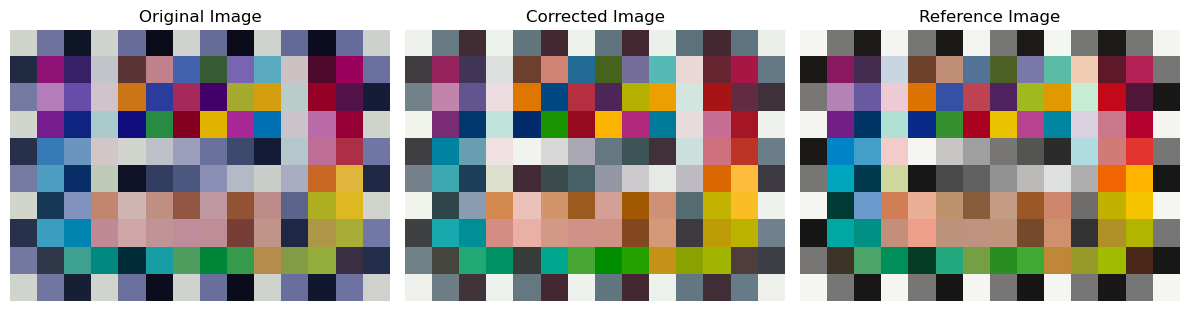

In [17]:
# Function to convert XYZ to sRGB for visualization
def xyz_to_srgb(xyz):
    srgb = color.xyz2rgb(xyz)  # Convert XYZ to sRGB
    srgb = np.clip(srgb, 0, 1)  # Clip values to valid range
    return (srgb * 255).astype(np.uint16)  # Convert to 8-bit image

# Convert images to sRGB
original_srgb = xyz_to_srgb(xyz_input)
corrected_srgb = xyz_to_srgb(corrected_xyz_image)
reference_srgb = xyz_to_srgb(xyz_ref)

# Display original, corrected, and reference images side by side
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
titles = ["Original Image", "Corrected Image", "Reference Image"]
images = [original_srgb, corrected_srgb, reference_srgb]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()